epoch:     0  GD  loss: 11.435083  NDDA: 0.3070  min_eigenvalue: -0.043982  has_negative: True
epoch:     0  GD  loss: 11.435083  NDDA: 0.3070
epoch:    10  GD  loss: 11.423781  NDDA: 0.3160
epoch:    20  GD  loss: 11.412644  NDDA: 0.3150
epoch:    30  GD  loss: 11.401677  NDDA: 0.3240
epoch:    40  GD  loss: 11.390882  NDDA: 0.3100
epoch:    50  GD  loss: 11.380262  NDDA: 0.3410
epoch:    60  GD  loss: 11.369821  NDDA: 0.3510
epoch:    70  GD  loss: 11.359557  NDDA: 0.3440
epoch:    80  GD  loss: 11.349477  NDDA: 0.3670
epoch:    90  GD  loss: 11.339578  NDDA: 0.3720
epoch:   100  GD  loss: 11.329865  NDDA: 0.3620  min_eigenvalue: -0.029239  has_negative: True
epoch:   100  GD  loss: 11.329865  NDDA: 0.3620
epoch:   110  GD  loss: 11.320336  NDDA: 0.3520
epoch:   120  GD  loss: 11.310997  NDDA: 0.3640
epoch:   130  GD  loss: 11.301845  NDDA: 0.3690
epoch:   140  GD  loss: 11.292880  NDDA: 0.3730
epoch:   150  GD  loss: 11.284104  NDDA: 0.4010
epoch:   160  GD  loss: 11.275517  NDDA: 0

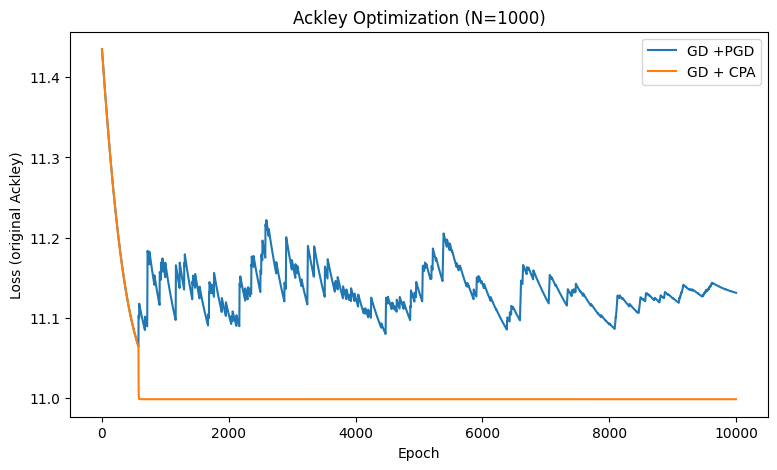

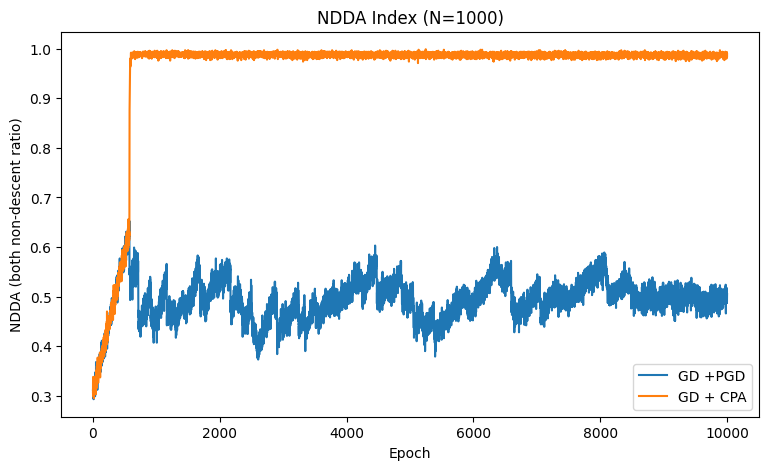

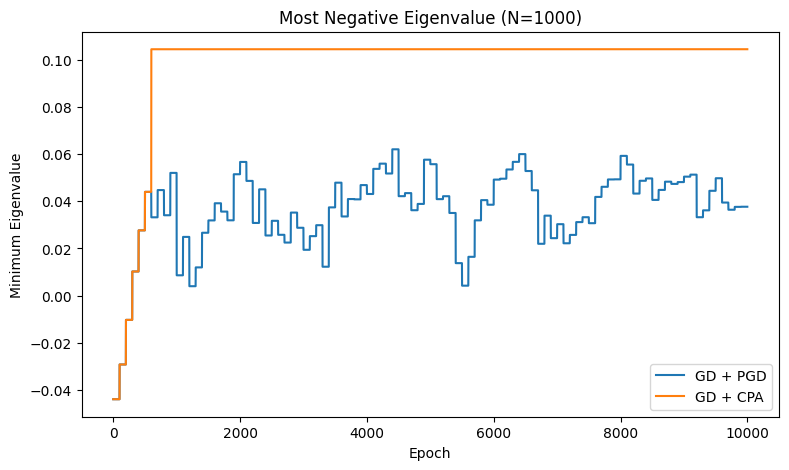

In [2]:
import torch
import numpy as np
import math
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------------------
# Loss functions (unchanged)
# ----------------------------------------------------------------------
def loss_function(x):
    return -20*torch.exp(-0.2*torch.sqrt(torch.mean(x**2))) - torch.exp(torch.mean(torch.cos(2*math.pi*x))) + 20 + math.e

def triple_log_exp_loss(x):
    orig_loss = loss_function(x)
    floor = torch.div(orig_loss, 1, rounding_mode='trunc').detach()
    temp_2 = torch.log(orig_loss - floor + 30)
    floor_2 = torch.div(temp_2, 1, rounding_mode='trunc').detach()
    temp_3 = torch.log(temp_2 - floor_2 + 30)
    floor_3 = torch.div(temp_3, 1, rounding_mode='trunc').detach()
    temp_4 = torch.log(temp_3 - floor_3 + 30)
    floor_4 = torch.div(temp_4, 1, rounding_mode='trunc').detach()
    temp_5 = torch.log(temp_4 - floor_4 + 30)
    floor_5 = torch.div(temp_5, 1, rounding_mode='trunc').detach()
    return torch.log(temp_5 - floor_5 + 30)

# ----------------------------------------------------------------------
# NDDA computation (as defined in the paper)
# ----------------------------------------------------------------------
def compute_NDDA(params, alpha=1.3, sigma=0.05):
    """
    Returns the NDDA index: fraction of coordinates where BOTH
    I1_i >= 0 and I2_i >= 0.
    """
    params = params.clone().detach().to(device).requires_grad_(True)
    d = params.numel()

    # First probe
    epsilon = sigma * torch.randn_like(params)
    params1 = params + epsilon
    E1 = loss_function(params1)
    E1.backward()
    I1 = epsilon * params.grad
    params.grad.zero_()

    # Build epsilon' with amplification
    mask_descent = (I1 < 0).to(device)    # original direction is descent
    mask_ascent  = (I1 > 0).to(device)    # original direction is ascent
    epsilon_prime = torch.where(mask_descent, alpha * epsilon, epsilon)
    epsilon_prime = torch.where(mask_ascent, -epsilon, epsilon_prime)

    params2 = params + epsilon_prime
    E2 = loss_function(params2)
    E2.backward()
    I2 = epsilon_prime * params.grad
    params.grad.zero_()

    # NDDA = coordinates where both probes are non‑descent
    ndda_count = torch.sum((I1 >= 0) & (I2 >= 0)).float()
    return (ndda_count / d).item()

# ----------------------------------------------------------------------
# CPA optimizer with Hessian analysis (formerly "optimize_stochastic")
# ----------------------------------------------------------------------
def optimize_CPA(params_init, alpha=1.3, sigma_begin=0.02, sigma_end=0.001, lr=0.001, epochs=10):
    """
    Controlled Perturbation Algorithm (CPA) – full optimizer.
    (The paper recommends using it only after reaching a stationary point.)
    """
    params = params_init.clone().detach().to(device).requires_grad_(True)
    losses = []
    ndda_vals = []
    min_eigenvalues = []
    d = params.numel()

    for epoch in range(epochs):
        # --- Two‑probe CPA ---
        sigma = sigma_begin * (1. - epoch/epochs) + sigma_end * epoch/epochs
        epsilon = (sigma * torch.randn_like(params)).detach().to(device).requires_grad_(False)
        params1 = params + epsilon
        E1 = loss_function(params1)
        E1.backward()
        I1 = epsilon * params.grad
        params.grad.zero_()

        mask_descent = (I1 < 0).to(device)
        mask_ascent  = (I1 > 0).to(device)
        epsilon_prime = torch.where(mask_descent, alpha * epsilon, epsilon)
        epsilon_prime = (torch.where(mask_ascent, -epsilon, epsilon_prime)).detach().to(device).requires_grad_(False)

        params2 = params + epsilon_prime
        E2 = loss_function(params2)
        E2.backward()
        I2 = epsilon_prime * params.grad
        params.grad.zero_()

        # Full CPA update: I2 < 0, or (I1 < 0 and I2 >= 0)
        update_mask = (I2 < 0) | ((I1 < 0) & (I2 >= 0)).to(device)
        perturbation = torch.where((I2 < 0), epsilon_prime, epsilon)
        perturbation = perturbation * update_mask.float()

        with torch.no_grad():
            params += perturbation
            final_loss = loss_function(params)   # record actual loss
            losses.append(final_loss.item())

        # NDDA after update
        ndda_vals.append(compute_NDDA(params, alpha=alpha, sigma=sigma))

        # ---- Hessian analysis every 100 epochs ----
        if epoch % 100 == 0:
            mu_Hessian = params.clone().detach().to(device).requires_grad_(True)
            y = loss_function(mu_Hessian)    # Hessian computed on the original loss
            grad = torch.autograd.grad(y, mu_Hessian, create_graph=True)[0]

            dim = mu_Hessian.shape[0]
            H = torch.zeros(dim, dim)
            for i in range(dim):
                grad2 = torch.autograd.grad(grad[i], mu_Hessian, create_graph=True)[0]
                H[i] = grad2
            eigenvalues, _ = torch.linalg.eig(H)
            eigenvalues = eigenvalues.real
            min_eigenvalues.append(torch.min(eigenvalues).item())

            # Optional diagnostics
            has_negative = (eigenvalues < 0).any()
            print(f"epoch: {epoch:5d}  CPA  loss: {losses[-1]:.6f}  NDDA: {ndda_vals[-1]:.4f}  "
                  f"min_eigenvalue: {min_eigenvalues[-1]:.6f}  has_negative: {has_negative}")
        else:
            if len(min_eigenvalues) > 0:
                min_eigenvalues.append(min_eigenvalues[-1])
            else:
                min_eigenvalues.append(None)

        if epoch % 10 == 0:
            print(f"epoch: {epoch:5d}  CPA  loss: {losses[-1]:.6f}  NDDA: {ndda_vals[-1]:.4f}")

    return params, losses, ndda_vals, min_eigenvalues

# ----------------------------------------------------------------------
# GD / PGD optimizer with Hessian analysis (formerly "optimize")
# ----------------------------------------------------------------------

def switch_to_CPA(params_init, sigma = 0.2, alpha=1.3):
    """
    Controlled Perturbation Algorithm (CPA) – full optimizer.
    (The paper recommends using it only after reaching a stationary point.)
    """
    params = params_init.clone().detach().to(device).requires_grad_(True)
    losses = []
    ndda_vals = []
    min_eigenvalues = []
    d = params.numel()

    epsilon = (sigma * torch.randn_like(params)).detach().to(device).requires_grad_(False)
    params1 = params + epsilon
    E1 = loss_function(params1)
    E1.backward()
    I1 = epsilon * params.grad
    params.grad.zero_()

    mask_descent = (I1 < 0).to(device)
    mask_ascent  = (I1 > 0).to(device)
    epsilon_prime = torch.where(mask_descent, alpha * epsilon, epsilon)
    epsilon_prime = (torch.where(mask_ascent, -epsilon, epsilon_prime)).detach().to(device).requires_grad_(False)

    params2 = params + epsilon_prime
    E2 = loss_function(params2)
    E2.backward()
    I2 = epsilon_prime * params.grad
    params.grad.zero_()

        # Full CPA update: I2 < 0, or (I1 < 0 and I2 >= 0)
    update_mask = (I2 < 0) | ((I1 < 0) & (I2 >= 0)).to(device)
    perturbation = torch.where((I2 < 0), epsilon_prime, epsilon)
    perturbation = perturbation * update_mask.float()

    with torch.no_grad():
        params += perturbation
    return params



def optimize_GD_then_PGD_or_CPA(params_init, sigma_begin=0.02, sigma_end=0.001, escape_method = "CPA", epochs=10):
    """
    Gradient Descent (GD) or Perturbed Gradient Descent (PGD).
    """
    method="GD"
    params = params_init.clone().detach().to(device).requires_grad_(True)
    losses = []
    ndda_vals = []
    min_eigenvalues = []

    for epoch in range(epochs):
        lrlr = sigma_begin * (1. - epoch/epochs) + sigma_end * epoch/epochs  # original learning rate schedule
        energy = loss_function(params)
        losses.append(loss_function(params).item())   # record actual loss
        

        if method == "GD":
            energy.backward()
            with torch.no_grad():
                params -= lrlr * params.grad
        elif method == "PGD":
            energy.backward()
            with torch.no_grad():
                noise = torch.randn_like(params)
                params -= lrlr * (params.grad + noise)
        elif method == "CPA":
            params = switch_to_CPA(params, sigma=lrlr)


        params.grad.zero_()
        ndda_vals.append(compute_NDDA(params, alpha=1.3, sigma=0.05))



        params_temp = params.clone().detach().to(device).requires_grad_(True)
        y = loss_function(params_temp)
        grad = torch.autograd.grad(y, params_temp, create_graph=True)[0]
        max_grad_norm = torch.max(torch.abs(grad)).item()
        if max_grad_norm < 1.5e-2:
            temp = method
            method = escape_method
            if temp != escape_method:
                print(f"Switching to {escape_method} at epoch {epoch} due to small gradient norm: {max_grad_norm:.5e}")
        else:
            temp = method
            method="GD"
            if temp != "GD":
                print(f"Switching back to GD at epoch {epoch} due to large gradient norm: {max_grad_norm:.5e}")       
        # Hessian analysis every 100 epochs
        if epoch % 100 == 0:
            mu_Hessian = params.clone().detach().to(device).requires_grad_(True)
            y = loss_function(mu_Hessian)
            grad = torch.autograd.grad(y, mu_Hessian, create_graph=True)[0]

            dim = mu_Hessian.shape[0]
            H = torch.zeros(dim, dim)
            for i in range(dim):
                grad2 = torch.autograd.grad(grad[i], mu_Hessian, create_graph=True)[0]
                H[i] = grad2
            eigenvalues, _ = torch.linalg.eig(H)
            eigenvalues = eigenvalues.real
            min_eigenvalues.append(torch.min(eigenvalues).item())

            has_negative = (eigenvalues < 0).any()
            print(f"epoch: {epoch:5d}  {method}  loss: {losses[-1]:.6f}  NDDA: {ndda_vals[-1]:.4f}  "
                  f"min_eigenvalue: {min_eigenvalues[-1]:.6f}  has_negative: {has_negative}")
        else:
            if len(min_eigenvalues) > 0:
                min_eigenvalues.append(min_eigenvalues[-1])
            else:
                min_eigenvalues.append(None)

        if epoch % 10 == 0:
            print(f"epoch: {epoch:5d}  {method}  loss: {losses[-1]:.6f}  NDDA: {ndda_vals[-1]:.4f}")

    return params, losses, ndda_vals, min_eigenvalues

# ----------------------------------------------------------------------
# Run experiment
# ----------------------------------------------------------------------
N = 1000
epoch_no = 10000
torch.manual_seed(0)

# Initial parameters (same as original)
params0 = 4 + 0.1 * torch.randn(N, device=device)

# CPA (sigma=0.001, as original "factor_training")
params_cpa, cpa_losses, cpa_ndda, cpa_min_eig = optimize_GD_then_PGD_or_CPA(
    params0, sigma_begin=0.02, sigma_end=0.001, escape_method ="CPA", epochs=epoch_no
)

# PGD
params_pgd, pgd_losses, pgd_ndda, pgd_min_eig = optimize_GD_then_PGD_or_CPA(
    params0, sigma_begin=0.02, sigma_end=0.001, escape_method="PGD", epochs=epoch_no
)




print("GD + CPA final loss:", cpa_losses[-1])
print("GD + PGD final loss:", pgd_losses[-1])

# ----------------------------------------------------------------------
# Plots
# ----------------------------------------------------------------------
# Energy
plt.figure(figsize=(9,5))
plt.plot(pgd_losses, label="GD +PGD")
plt.plot(cpa_losses, label="GD + CPA")
plt.xlabel("Epoch")
plt.ylabel("Loss (original Ackley)")
plt.legend()
plt.title(f"Ackley Optimization (N={N})")
plt.savefig("ackley_energy.png")
plt.show()
plt.close()

# NDDA index
plt.figure(figsize=(9,5))
plt.plot(pgd_ndda, label="GD +PGD")
plt.plot(cpa_ndda, label="GD + CPA")
plt.xlabel("Epoch")
plt.ylabel("NDDA (both non-descent ratio)")
plt.legend()
plt.title(f"NDDA Index (N={N})")
plt.savefig("ackley_ndda.png")
plt.show()
plt.close()

# Most negative eigenvalue (min eigenvalue)
plt.figure(figsize=(9,5))
pgd_eig = np.array([v if v is not None else np.nan for v in pgd_min_eig])
cpa_eig = np.array([v if v is not None else np.nan for v in cpa_min_eig])

plt.plot(pgd_eig, label="GD + PGD")
plt.plot(cpa_eig, label="GD + CPA")
plt.xlabel("Epoch")
plt.ylabel("Minimum Eigenvalue")
plt.legend()
plt.title(f"Most Negative Eigenvalue (N={N})")
plt.savefig("ackley_min_eigenvalue.png")
plt.show()
plt.close()